# Climate and Hazard Features

**Purpose.** Annual county climate measurements and FEMA/NOAA hazard outcomes.

This notebook is a read-only diagnostic consumer of the current `feature.*` layer. All transformations and canonical ACS mappings are owned by `src/cli/build_database.py`.

## Setup and current feature definitions

In [1]:
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 150)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
while not (ROOT / "data" / "housing_predict.duckdb").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DB_PATH = ROOT / "data" / "housing_predict.duckdb"
if not DB_PATH.exists():
    raise FileNotFoundError("Run `python -m src.cli.build_database` from the project root first.")

con = duckdb.connect(str(DB_PATH), read_only=True)
FEATURE_TABLES = ['county_climate_annual', 'county_fema_annual', 'county_noaa_storm_annual']

available = {row[0] for row in con.execute(
    "SELECT table_name FROM information_schema.tables WHERE table_schema = 'feature'"
).fetchall()}
missing = sorted(set(FEATURE_TABLES) - available)
if missing:
    raise RuntimeError(
        f"Database is missing current feature tables {missing}. "
        "Run `python -m src.cli.build_database` to rebuild it."
    )

registry_available = "canonical_feature_registry" in available
if registry_available:
    placeholders = ", ".join("?" for _ in FEATURE_TABLES)
    source_tables = [{
        "county_economic_annual": "dp03",
        "county_social_annual": "dp02",
        "county_housing": "dp04",
    }.get(table) for table in FEATURE_TABLES]
    source_tables = [table for table in source_tables if table]
    if source_tables:
        source_placeholders = ", ".join("?" for _ in source_tables)
        registry = con.execute(
            f"SELECT feature_name, acs_table, unit, min(year) AS first_year, "
            f"max(year) AS last_year, count(*) AS mapped_years "
            f"FROM feature.canonical_feature_registry WHERE acs_table IN ({source_placeholders}) "
            f"GROUP BY 1,2,3 ORDER BY 2,1",
            source_tables,
        ).df()
    else:
        registry = pd.DataFrame(columns=["feature_name", "acs_table", "unit", "first_year", "last_year", "mapped_years"])
else:
    registry = pd.DataFrame()
display(registry)

,feature_name,acs_table,unit,first_year,last_year,mapped_years


## Table inventory and county-year grain

In [2]:
inventory = []
for table in FEATURE_TABLES:
    schema = con.execute(f"DESCRIBE feature.{table}").df()
    row_count, distinct_keys, min_year, max_year = con.execute(
        f"SELECT count(*), count(DISTINCT (county_fips, year)), min(year), max(year) FROM feature.{table}"
    ).fetchone()
    inventory.append({
        "feature_table": table,
        "rows": row_count,
        "distinct_county_years": distinct_keys,
        "duplicate_county_years": row_count - distinct_keys,
        "first_year": min_year,
        "last_year": max_year,
        "feature_columns": len(schema) - len({"county_fips", "year", "county_name"} & set(schema["column_name"])),
    })
inventory = pd.DataFrame(inventory)
display(inventory)
assert (inventory["duplicate_county_years"] == 0).all(), "Feature tables must be unique by county and year."

,feature_table,rows,distinct_county_years,duplicate_county_years,first_year,last_year,feature_columns
0,county_climate_annual,24045,24045,0,2010,2024,4
1,county_fema_annual,17705,17705,0,2010,2024,1
2,county_noaa_storm_annual,46708,46708,0,2010,2024,4


## Completeness by feature and year

In [3]:
completeness = []
identifier_columns = {"county_fips", "year", "county_name"}
for table in FEATURE_TABLES:
    columns = con.execute(f"DESCRIBE feature.{table}").df()["column_name"].tolist()
    for column in [column for column in columns if column not in identifier_columns]:
        quoted = '"' + column.replace('"', '""') + '"'
        rows = con.execute(
            f"SELECT year, count(*) AS rows, count({quoted}) AS nonnull_rows "
            f"FROM feature.{table} GROUP BY year ORDER BY year"
        ).df()
        rows["feature_table"] = table
        rows["feature_name"] = column
        rows["completeness_pct"] = 100 * rows["nonnull_rows"] / rows["rows"]
        completeness.append(rows)
completeness = pd.concat(completeness, ignore_index=True)
display(completeness.groupby(["feature_table", "feature_name"], as_index=False).agg(
    first_available_year=("year", lambda s: completeness.loc[s.index][completeness.loc[s.index, "nonnull_rows"] > 0]["year"].min()),
    mean_completeness_pct=("completeness_pct", "mean"),
    minimum_completeness_pct=("completeness_pct", "min"),
).sort_values(["feature_table", "mean_completeness_pct"]))

,feature_table,feature_name,first_available_year,mean_completeness_pct,minimum_completeness_pct
0,county_climate_annual,avg_temperature_f,2010,100.0,100.0
1,county_climate_annual,max_temperature_f,2010,100.0,100.0
2,county_climate_annual,min_temperature_f,2010,100.0,100.0
3,county_climate_annual,precipitation_inches,2010,100.0,100.0
4,county_fema_annual,disaster_count,2010,100.0,100.0
5,county_noaa_storm_annual,storm_damage_usd,2010,100.0,100.0
6,county_noaa_storm_annual,storm_deaths,2010,100.0,100.0
7,county_noaa_storm_annual,storm_event_count,2010,100.0,100.0
8,county_noaa_storm_annual,storm_injuries,2010,100.0,100.0


## Distributions and range checks

In [4]:
summaries = []
for table in FEATURE_TABLES:
    schema = con.execute(f"DESCRIBE feature.{table}").df()
    numeric = schema.loc[
        schema["column_type"].str.contains("DOUBLE|FLOAT|DECIMAL|INTEGER|BIGINT", case=False, regex=True),
        "column_name",
    ].tolist()
    for column in [column for column in numeric if column != "year"]:
        q = '"' + column.replace('"', '""') + '"'
        values = con.execute(f"SELECT {q} FROM feature.{table} WHERE {q} IS NOT NULL").df().iloc[:, 0]
        if values.empty:
            continue
        q1, q3 = values.quantile([0.25, 0.75])
        iqr = q3 - q1
        summaries.append({
            "feature_table": table, "feature_name": column, "count": len(values),
            "min": values.min(), "median": values.median(), "mean": values.mean(), "max": values.max(),
            "iqr_outliers": int(((values < q1 - 1.5 * iqr) | (values > q3 + 1.5 * iqr)).sum()),
            "outside_percent_range": int(((values < 0) | (values > 100)).sum()) if column.endswith("_pct") else np.nan,
        })
summaries = pd.DataFrame(summaries)
display(summaries)
assert summaries["outside_percent_range"].fillna(0).eq(0).all(), "Percentage feature outside [0, 100]."

,feature_table,feature_name,count,min,median,mean,max,iqr_outliers,outside_percent_range
0,county_climate_annual,avg_temperature_f,24045,33.016667,52.00,5.373309e+01,7.856667e+01,0,NaN
1,county_climate_annual,min_temperature_f,24045,-17.100000,19.90,2.005088e+01,6.470000e+01,72,NaN
2,county_climate_annual,max_temperature_f,24045,55.400000,86.50,8.669943e+01,1.122000e+02,130,NaN
3,county_climate_annual,precipitation_inches,24045,2.060000,41.16,4.064672e+01,1.324800e+02,176,NaN
4,county_fema_annual,disaster_count,17705,1.000000,1.00,1.685287e+00,1.000000e+01,1192,NaN
5,county_noaa_storm_annual,storm_event_count,46708,1.000000,14.00,1.887221e+01,5.880000e+02,2291,NaN
6,county_noaa_storm_annual,storm_damage_usd,46708,0.000000,25000.00,7.414546e+06,1.850011e+10,7782,NaN
7,county_noaa_storm_annual,storm_injuries,46708,0.000000,0.00,7.336002e-01,1.404000e+03,4136,NaN
8,county_noaa_storm_annual,storm_deaths,46708,0.000000,0.00,1.565256e-01,1.590000e+02,3270,NaN


## Correlation and redundancy

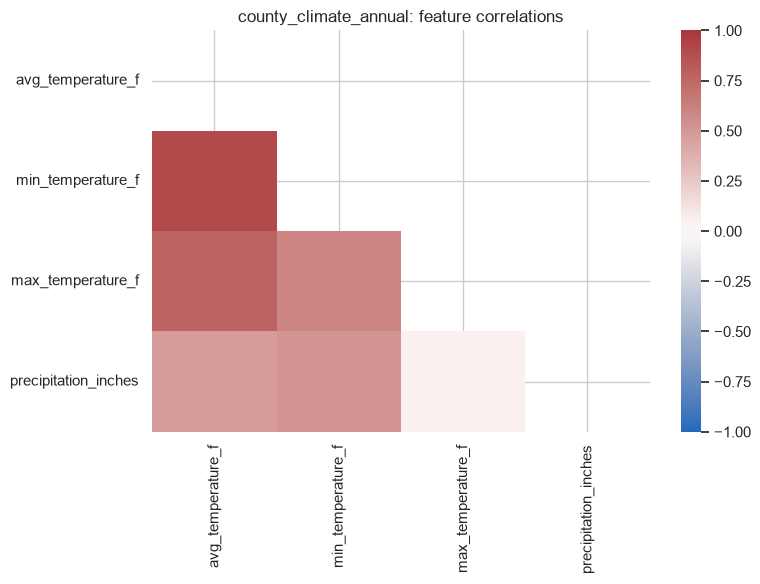

,feature_a,feature_b,correlation,abs_correlation
4,min_temperature_f,avg_temperature_f,0.905223,0.905223
8,max_temperature_f,avg_temperature_f,0.778297,0.778297
9,max_temperature_f,min_temperature_f,0.597660,0.597660
13,precipitation_inches,min_temperature_f,0.508910,0.508910
12,precipitation_inches,avg_temperature_f,0.479680,0.479680
14,precipitation_inches,max_temperature_f,0.047505,0.047505
0,avg_temperature_f,avg_temperature_f,NaN,NaN
1,avg_temperature_f,min_temperature_f,NaN,NaN
2,avg_temperature_f,max_temperature_f,NaN,NaN
3,avg_temperature_f,precipitation_inches,NaN,NaN


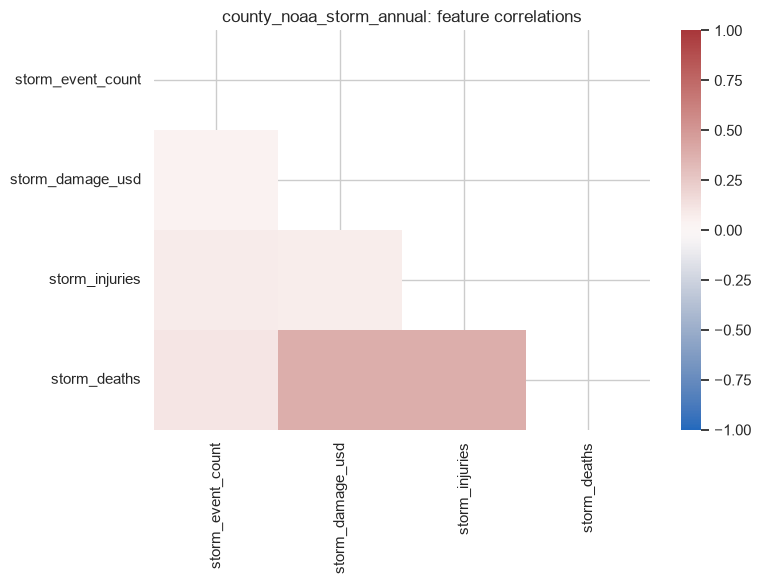

,feature_a,feature_b,correlation,abs_correlation
14,storm_deaths,storm_injuries,0.388764,0.388764
13,storm_deaths,storm_damage_usd,0.386477,0.386477
12,storm_deaths,storm_event_count,0.110282,0.110282
8,storm_injuries,storm_event_count,0.082420,0.082420
9,storm_injuries,storm_damage_usd,0.073733,0.073733
4,storm_damage_usd,storm_event_count,0.042662,0.042662
0,storm_event_count,storm_event_count,NaN,NaN
1,storm_event_count,storm_damage_usd,NaN,NaN
2,storm_event_count,storm_injuries,NaN,NaN
3,storm_event_count,storm_deaths,NaN,NaN


In [5]:
for table in FEATURE_TABLES:
    frame = con.execute(f"SELECT * FROM feature.{table}").df()
    numeric = frame.select_dtypes(include=np.number).drop(columns=["year"], errors="ignore")
    if numeric.shape[1] < 2:
        continue
    corr = numeric.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    fig, ax = plt.subplots(figsize=(max(8, 0.45 * len(corr)), max(6, 0.4 * len(corr))))
    sns.heatmap(corr, mask=mask, cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title(f"{table}: feature correlations")
    plt.tight_layout()
    plt.show()

    pairs = corr.where(~mask).stack().rename("correlation").reset_index()
    pairs.columns = ["feature_a", "feature_b", "correlation"]
    display(pairs.assign(abs_correlation=pairs["correlation"].abs()).sort_values("abs_correlation", ascending=False).head(20))

## Temporal coverage and trends

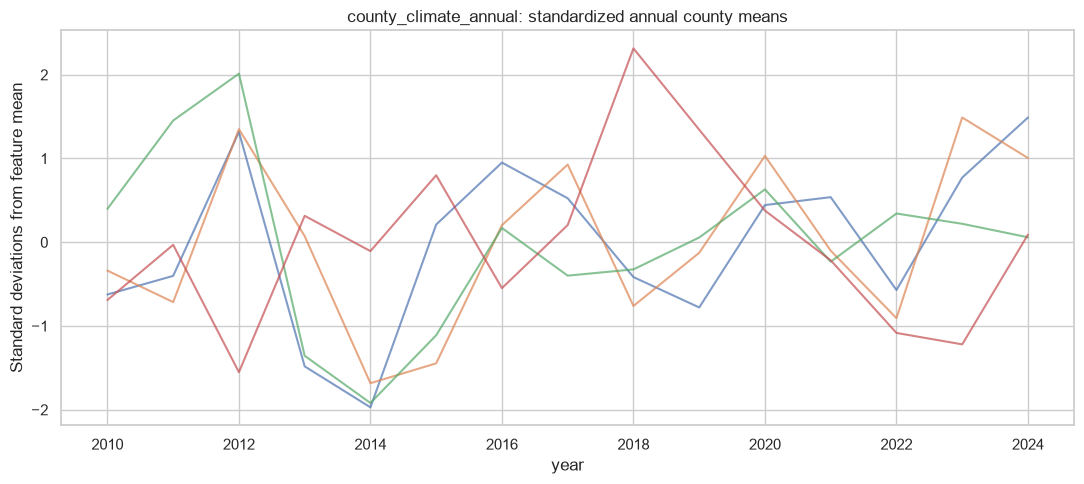

,year,avg_temperature_f,min_temperature_f,max_temperature_f,precipitation_inches
0,2010,53.016173,18.973799,87.219838,38.740749
1,2011,53.271616,17.778665,88.598129,40.560911
2,2012,55.244947,24.341859,89.329757,36.360799
3,2013,52.030724,20.282034,84.927636,41.517112
4,2014,51.469224,14.701123,84.190518,40.353631
5,2015,53.975286,15.454710,85.247723,42.854585
6,2016,54.824990,20.696881,86.921647,39.132190
7,2017,54.335579,22.997692,86.177792,41.213518
8,2018,53.255199,17.631691,86.275421,47.037124
9,2019,52.838600,19.649407,86.772988,44.357342


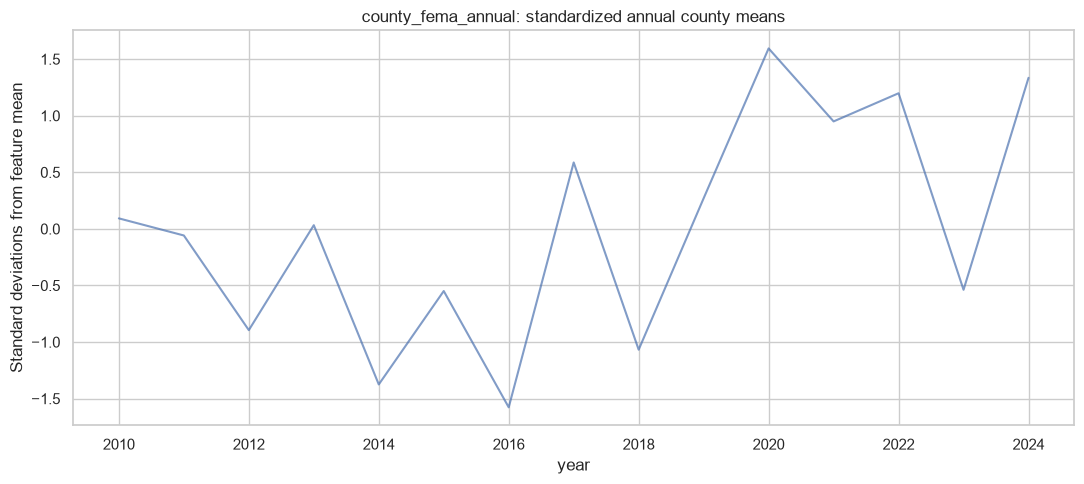

,year,disaster_count
0,2010,1.689684
1,2011,1.647405
2,2012,1.413516
3,2013,1.672832
4,2014,1.279330
5,2015,1.510145
6,2016,1.222766
7,2017,1.827820
8,2018,1.365194
9,2019,1.739333


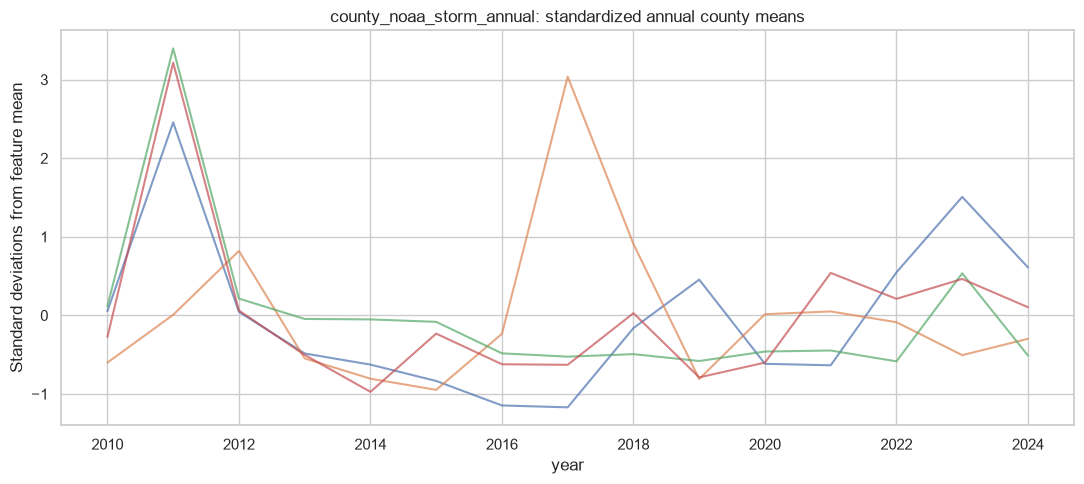

,year,storm_event_count,storm_damage_usd,storm_injuries,storm_deaths
0,2010,18.976474,3.723934e+06,0.808250,0.141154
1,2011,23.883564,7.450100e+06,2.857832,0.336121
2,2012,18.958413,1.243154e+07,0.867242,0.159949
3,2013,17.875162,4.048927e+06,0.705369,0.128396
4,2014,17.585288,2.470951e+06,0.701574,0.102152
5,2015,17.160039,1.600248e+06,0.682186,0.143550
6,2016,16.522992,5.970695e+06,0.431671,0.121762
7,2017,16.474673,2.601901e+07,0.405225,0.121376
8,2018,18.535216,1.296923e+07,0.425187,0.158066
9,2019,19.795644,2.443853e+06,0.370596,0.112428


In [6]:
for table in FEATURE_TABLES:
    schema = con.execute(f"DESCRIBE feature.{table}").df()
    numeric = schema.loc[schema["column_type"].str.contains("DOUBLE|FLOAT|DECIMAL|INTEGER|BIGINT", case=False), "column_name"].tolist()
    numeric = [column for column in numeric if column != "year"]
    if not numeric:
        continue
    expressions = ", ".join(f'avg("{column}") AS "{column}"' for column in numeric)
    annual = con.execute(f"SELECT year, {expressions} FROM feature.{table} GROUP BY year ORDER BY year").df()
    normalized = annual.set_index("year").apply(lambda s: (s - s.mean()) / s.std() if s.std() else 0)
    fig, ax = plt.subplots(figsize=(11, 5))
    normalized.plot(ax=ax, legend=False, alpha=0.7)
    ax.set_title(f"{table}: standardized annual county means")
    ax.set_ylabel("Standard deviations from feature mean")
    plt.tight_layout()
    plt.show()
    display(annual)

con.close()

## Interpretation notes

- ACS values are five-year estimates associated with their release year. Adjacent years therefore contain overlapping survey periods. Five-year estimates are favored over one-year estimates in this project because the former offers complete annual data over the time period defined in the project's scope, while the latter does not.
- Monetary ACS features and the housing target are expressed in 2024 dollars.
- A null before a feature's `first_year` can indicate that ACS had not yet published a reconciled definition.
- `target_median_owner_occupied_home_value_2024_usd` is the official DP04 median, because DP04 does not publish a county average housing-unit value.
- The canonical registry and transactional build are the authority for cross-year compatibility.